The work contained here is mine and mine only

# ENVIRONMENT SETUP

In [ ]:
import pandas as pd # for data viz and wrangling
import numpy as np # for 'numeric python'
import matplotlib.pyplot as plt # for data viz (more complex than pylab)
import seaborn as sns
from pylab import * # for data viz (import * means 'import all of the functions')

from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix, roc_curve, auc, make_scorer
from sklearn import metrics
from scipy import stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [ ]:
# mount your google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# LOAD THE DATA - SPOTIFY

1. Read in the Spotify dataset and determine how many rows and columns it has.


In [ ]:
df_spotify = pd.read_csv('/content/drive/MyDrive/OPIM 5604 Python/Datasets/spotify-2023 (4).csv', encoding='latin-1')

In [ ]:
#find spotify dataset rows and columns
df_spotify.shape

(953, 24)

The data has 953 rows and 24 columns/features

In [ ]:
# Preview
print(df_spotify.head())

                            track_name    artist(s)_name  artist_count  \
0  Seven (feat. Latto) (Explicit Ver.)  Latto, Jung Kook             2   
1                                 LALA       Myke Towers             1   
2                              vampire    Olivia Rodrigo             1   
3                         Cruel Summer      Taylor Swift             1   
4                       WHERE SHE GOES         Bad Bunny             1   

   released_year  released_month  released_day  in_spotify_playlists  \
0           2023               7            14                   553   
1           2023               3            23                  1474   
2           2023               6            30                  1397   
3           2019               8            23                  7858   
4           2023               5            18                  3133   

   in_spotify_charts    streams  in_apple_playlists  ...  bpm key   mode  \
0                147  141381703               

2. The target variable for this dataset is the streams column.  Check the datatype of streams.  If it isn’t already int64, update it.  Hint: if needed, drop a row of problematic data to get it to convert properly.


In [ ]:
df_spotify.dtypes

,0
artist_count,int64
released_year,int64
released_month,int64
released_day,int64
in_spotify_playlists,int64
in_spotify_charts,int64
streams,float64
in_apple_playlists,int64
in_apple_charts,int64
in_deezer_playlists,int64


In [ ]:
# Convert streams and other object columns to numeric (handling commas and errors)
df_spotify['streams'] = pd.to_numeric(df_spotify['streams'], errors='coerce')
for col in ['in_deezer_playlists', 'in_shazam_charts']:
    df_spotify[col] = pd.to_numeric(df_spotify[col].astype(str).str.replace(',', ''), errors='coerce')

Converted the streams from float64 to int64 along with in_deezer_playlists and in_shazam columns

In [ ]:
# Drop rows where target 'streams' is missing and drop identifier columns
df_spotify = df_spotify.dropna(subset=['streams'])
df_spotify = df_spotify.drop(columns=['track_name', 'artist(s)_name'])
df_spotify = df_spotify.fillna(0) # Simple fill for remaining NaNs in features

In [ ]:
# Create dummy variables for 'key' and 'mode'
df_spotify = pd.get_dummies(df_spotify, columns=['key', 'mode'], drop_first=True)

In [ ]:
# Define the target variable
target_s = 'streams'
features_s = df_spotify.drop(target_s, axis=1)
target_variable_s = df_spotify[target_s]

3. Partition the data into a 60/20/20 split.

In [ ]:
# Partition the data 60/20/20
# Split into 80% training/val and 20% test
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(features_s, target_variable_s, test_size=0.2, random_state=42)
# Split the 80% into 60% training and 20% validation (0.25 * 0.8 = 0.2)
X_train_s, X_val_s, y_train_s, y_val_s = train_test_split(X_train_s, y_train_s, test_size=0.25, random_state=42)

print("\nSpotify Splits:")
print("Training set shape:", X_train_s.shape, y_train_s.shape)
print("Validation set shape:", X_val_s.shape, y_val_s.shape)
print("Test set shape:", X_test_s.shape, y_test_s.shape)


Spotify Splits:
Training set shape: (570, 31) (570,)
Validation set shape: (191, 31) (191,)
Test set shape: (191, 31) (191,)


# RANDOM FOREST

4. Build a random forest model with hyperparameter tuning to predict streams using all predictors.


5. Check model performance by partition with RMSE, R Squared, distribution of residuals, and actual by predicted plots.


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, mean_squared_error

# Define hyperparameter grid
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

neg_mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

rf_model = RandomForestRegressor(random_state=42)

# GridSearchCV with 5-fold cross-validation
rf_grid_search = GridSearchCV(
    rf_model,
    rf_param_grid,
    cv=5,
    scoring=neg_mse_scorer,
    n_jobs=-1,
    verbose=1
)

rf_grid_search.fit(X_train_s, y_train_s)

print('Best hyperparameters (Random Forest):', rf_grid_search.best_params_)
best_cv_rmse_rf = np.sqrt(-rf_grid_search.best_score_)
print(f'Best cross-validation RMSE: {best_cv_rmse_rf:,.0f}')

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best hyperparameters (Random Forest): {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation RMSE: 270,540,536


In [ ]:
# Train final Random Forest with best params
best_rf = RandomForestRegressor(**rf_grid_search.best_params_, random_state=42)
best_rf.fit(X_train_s, y_train_s)

# Predictions on each partition
y_train_pred_rf = best_rf.predict(X_train_s)
y_val_pred_rf   = best_rf.predict(X_val_s)
y_test_pred_rf  = best_rf.predict(X_test_s)

print('Random Forest trained with optimal hyperparameters.')

Random Forest trained with optimal hyperparameters.


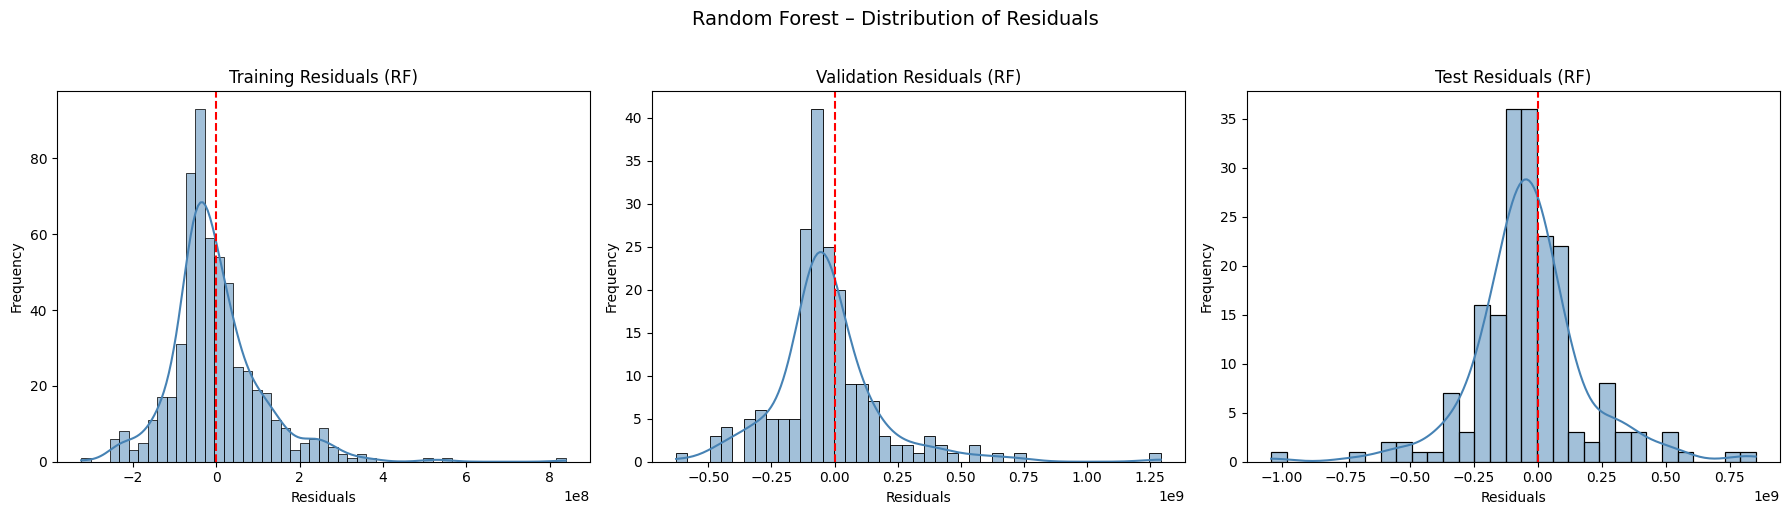

In [ ]:
# Distribution of Residuals – Random Forest
res_train_rf = y_train_s - y_train_pred_rf
res_val_rf   = y_val_s   - y_val_pred_rf
res_test_rf  = y_test_s  - y_test_pred_rf

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, res, title in zip(axes,
                           [res_train_rf, res_val_rf, res_test_rf],
                           ['Training Residuals (RF)', 'Validation Residuals (RF)', 'Test Residuals (RF)']):
    sns.histplot(res, kde=True, ax=ax, color='steelblue')
    ax.set_title(title)
    ax.set_xlabel('Residuals')
    ax.set_ylabel('Frequency')
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5)

plt.suptitle('Random Forest – Distribution of Residuals', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

6. Comment on the model performance.  What did you observe in the results? (5 on claude)


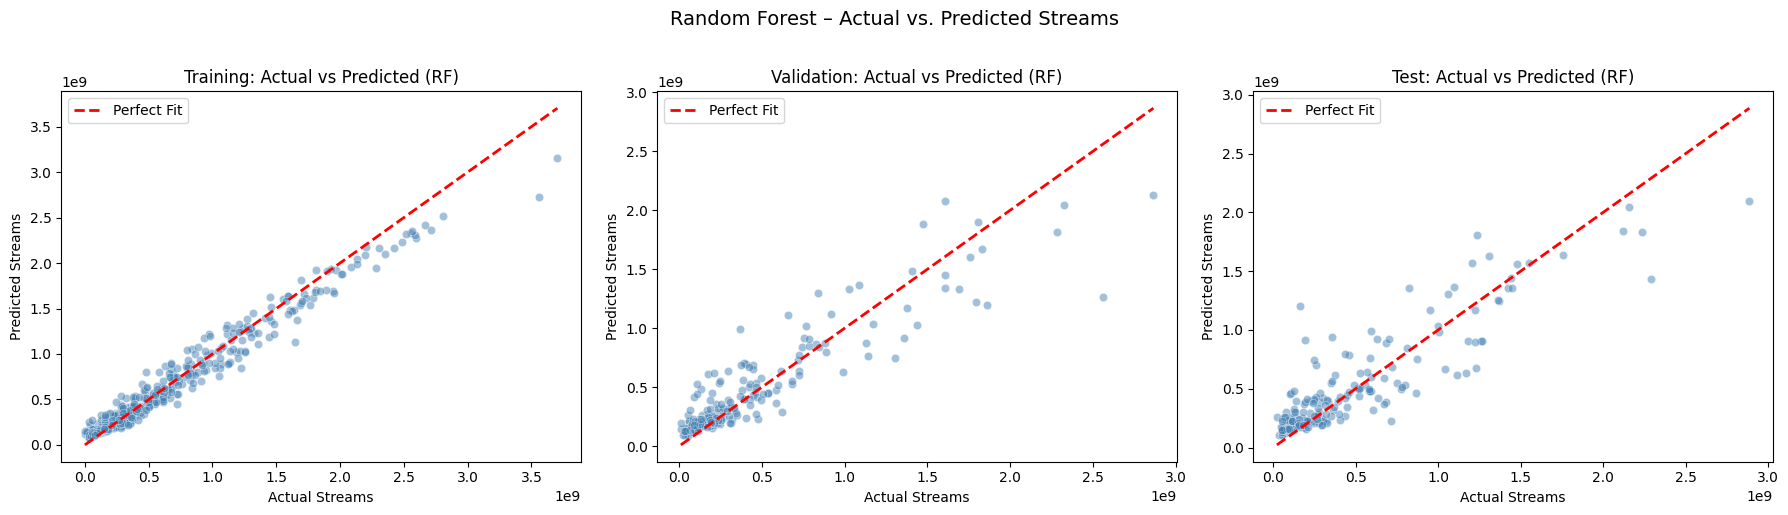

In [ ]:
# Actual vs. Predicted Plots – Random Forest
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, y_true, y_pred, title in zip(
    axes,
    [y_train_s, y_val_s, y_test_s],
    [y_train_pred_rf, y_val_pred_rf, y_test_pred_rf],
    ['Training: Actual vs Predicted (RF)', 'Validation: Actual vs Predicted (RF)', 'Test: Actual vs Predicted (RF)']
):
    sns.scatterplot(x=y_true, y=y_pred, ax=ax, alpha=0.5, color='steelblue')
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect Fit')
    ax.set_title(title)
    ax.set_xlabel('Actual Streams')
    ax.set_ylabel('Predicted Streams')
    ax.legend()

plt.suptitle('Random Forest – Actual vs. Predicted Streams', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The R-squared is higher on test and validation which shows some overfitting in the model. The RSME on validation and test is high compared to regular stream amounts which indicates some variance. The actual vs predicted streams scatterplots show a positive trend meaning the model caught a general pattern.

7. Check for feature importance.  Which variables are the most important?  Did any predictors go unused?


In [ ]:
# Extract feature importances from the tuned Random Forest
rf_importances = pd.Series(best_rf.feature_importances_, index=X_train_s.columns)
rf_importances_sorted = rf_importances.sort_values(ascending=False)

print('Feature Importances – Random Forest (descending):')
print(rf_importances_sorted)
print()
unused_rf = rf_importances_sorted[rf_importances_sorted == 0]
if len(unused_rf) > 0:
    print(f'Unused predictors (importance = 0): {unused_rf.index.tolist()}')
else:
    print('All predictors were used by the Random Forest.')

Feature Importances – Random Forest (descending):
in_spotify_playlists    0.229525
in_deezer_playlists     0.227675
in_apple_playlists      0.174029
released_year           0.106802
in_spotify_charts       0.031841
in_apple_charts         0.031400
in_deezer_charts        0.024552
released_day            0.021049
bpm                     0.018970
valence_%               0.017783
acousticness_%          0.015670
in_shazam_charts        0.013967
released_month          0.013729
danceability_%          0.013515
energy_%                0.013252
liveness_%              0.011786
speechiness_%           0.009312
key_C#                  0.005430
artist_count            0.003706
mode_Minor              0.002990
instrumentalness_%      0.002708
key_A#                  0.001643
key_G                   0.001637
key_A                   0.001594
key_F                   0.001114
key_D#                  0.001041
key_D                   0.000811
key_B                   0.000747
key_G#                  0.

# BOOSTED TREE

8. Build a boosted tree model with hyperparameter tuning to predict streams using all predictors.


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Define hyperparameter grid for GBR
gbr_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.10, 0.20],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 3]
}

gbr_model = GradientBoostingRegressor(random_state=42)

gbr_grid_search = GridSearchCV(
    gbr_model,
    gbr_param_grid,
    cv=5,
    scoring=neg_mse_scorer,
    n_jobs=-1,
    verbose=1
)

gbr_grid_search.fit(X_train_s, y_train_s)

print('Best hyperparameters (GBR):', gbr_grid_search.best_params_)
best_cv_rmse_gbr = np.sqrt(-gbr_grid_search.best_score_)
print(f'Best cross-validation RMSE: {best_cv_rmse_gbr:,.0f}')

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best hyperparameters (GBR): {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation RMSE: 250,437,728


In [ ]:
# Train final GBR model with best params
best_gbr = GradientBoostingRegressor(**gbr_grid_search.best_params_, random_state=42)
best_gbr.fit(X_train_s, y_train_s)

y_train_pred_gbr = best_gbr.predict(X_train_s)
y_val_pred_gbr   = best_gbr.predict(X_val_s)
y_test_pred_gbr  = best_gbr.predict(X_test_s)

# Define the get_regression_metrics function here
def get_regression_metrics(y_true, y_pred, partition_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'{partition_name} RMSE: {rmse:,.0f}')
    print(f'{partition_name} R-squared: {r2:.4f}')
    return rmse, r2

print('GBR – Performance by Partition')
print('-' * 55)
rmse_train_gbr, r2_train_gbr = get_regression_metrics(y_train_s, y_train_pred_gbr, 'Training')
rmse_val_gbr,   r2_val_gbr   = get_regression_metrics(y_val_s,   y_val_pred_gbr,   'Validation')
rmse_test_gbr,  r2_test_gbr  = get_regression_metrics(y_test_s,  y_test_pred_gbr,  'Test')

GBR – Performance by Partition
-------------------------------------------------------
Training RMSE: 144,184,619
Training R-squared: 0.9422
Validation RMSE: 185,384,801
Validation R-squared: 0.8750
Test RMSE: 213,231,398
Test R-squared: 0.8143


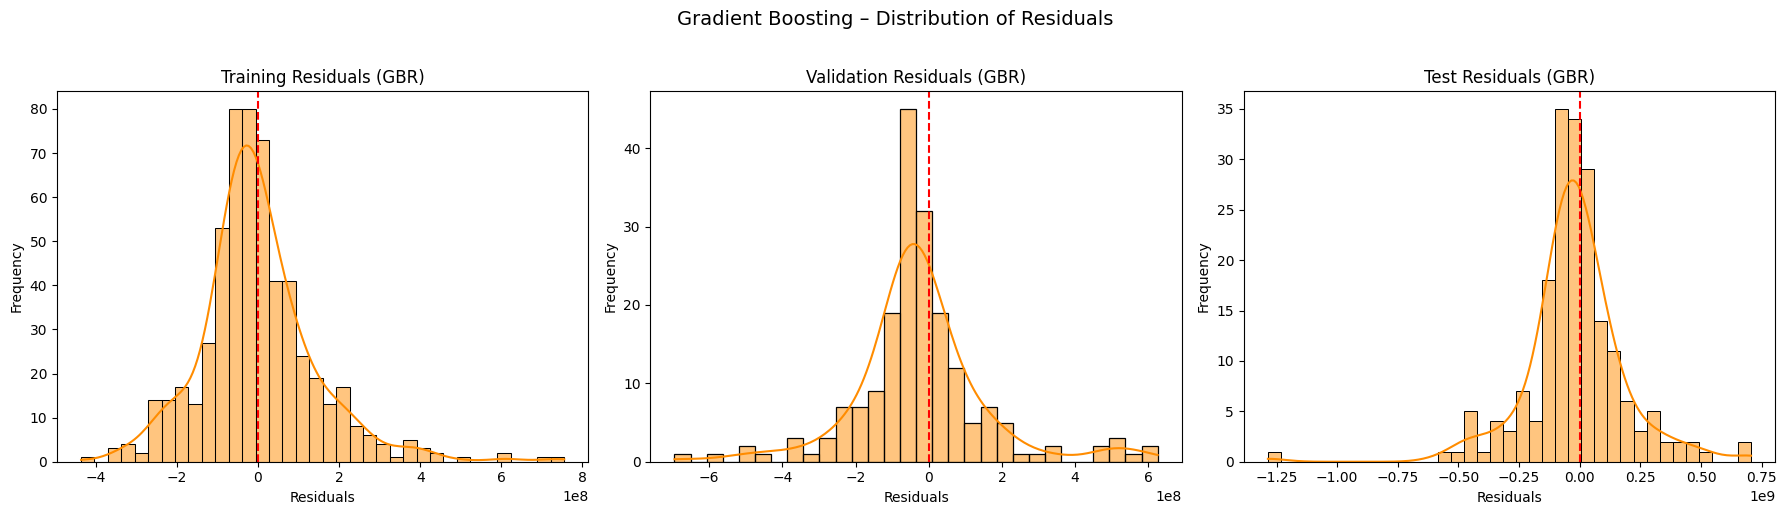

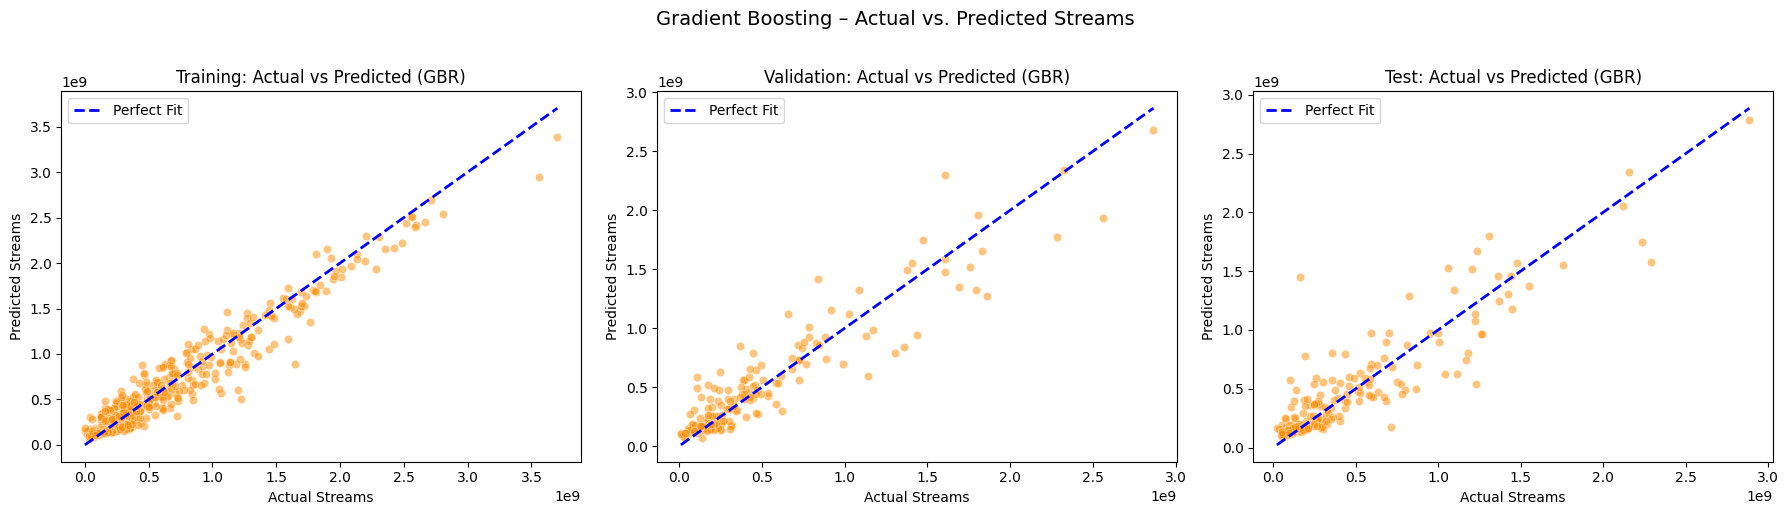

In [ ]:
# Distribution of Residuals – GBR
res_train_gbr = y_train_s - y_train_pred_gbr
res_val_gbr   = y_val_s   - y_val_pred_gbr
res_test_gbr  = y_test_s  - y_test_pred_gbr

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, res, title in zip(axes,
                           [res_train_gbr, res_val_gbr, res_test_gbr],
                           ['Training Residuals (GBR)', 'Validation Residuals (GBR)', 'Test Residuals (GBR)']):
    sns.histplot(res, kde=True, ax=ax, color='darkorange')
    ax.set_title(title)
    ax.set_xlabel('Residuals')
    ax.set_ylabel('Frequency')
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5)

plt.suptitle('Gradient Boosting – Distribution of Residuals', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Actual vs. Predicted – GBR
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, y_true, y_pred, title in zip(
    axes,
    [y_train_s, y_val_s, y_test_s],
    [y_train_pred_gbr, y_val_pred_gbr, y_test_pred_gbr],
    ['Training: Actual vs Predicted (GBR)', 'Validation: Actual vs Predicted (GBR)', 'Test: Actual vs Predicted (GBR)']
):
    sns.scatterplot(x=y_true, y=y_pred, ax=ax, alpha=0.5, color='darkorange')
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'b--', lw=2, label='Perfect Fit')
    ax.set_title(title)
    ax.set_xlabel('Actual Streams')
    ax.set_ylabel('Predicted Streams')
    ax.legend()

plt.suptitle('Gradient Boosting – Actual vs. Predicted Streams', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

9. Comment on the model performance.  What did you observe in the results?


There seems to be less overfitting with the Gradient Boosting than the random forest. Training RSME is a bit higher than the random forests but validation and test RSME is lower showing better generalization. The actual vs predicted scatter plots also show positive trends.

10. Check for feature importance.  Which variables are the most important?  Did any predictors go unused?


Feature Importances – Gradient Boosting (descending):
in_deezer_playlists     0.560947
in_spotify_playlists    0.255808
released_year           0.069022
in_apple_playlists      0.042580
in_spotify_charts       0.027949
released_month          0.005657
released_day            0.004937
in_apple_charts         0.004311
in_deezer_charts        0.004179
bpm                     0.004004
key_C#                  0.003870
in_shazam_charts        0.003474
valence_%               0.003249
danceability_%          0.002791
acousticness_%          0.002355
liveness_%              0.001686
energy_%                0.001335
key_G                   0.000857
mode_Minor              0.000585
artist_count            0.000178
speechiness_%           0.000167
instrumentalness_%      0.000061
key_A                   0.000000
key_B                   0.000000
key_A#                  0.000000
key_D                   0.000000
key_D#                  0.000000
key_F                   0.000000
key_E                 

/tmp/ipykernel_26055/3212107867.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gbr_importances_sorted.values, y=gbr_importances_sorted.index, palette='Oranges_r')


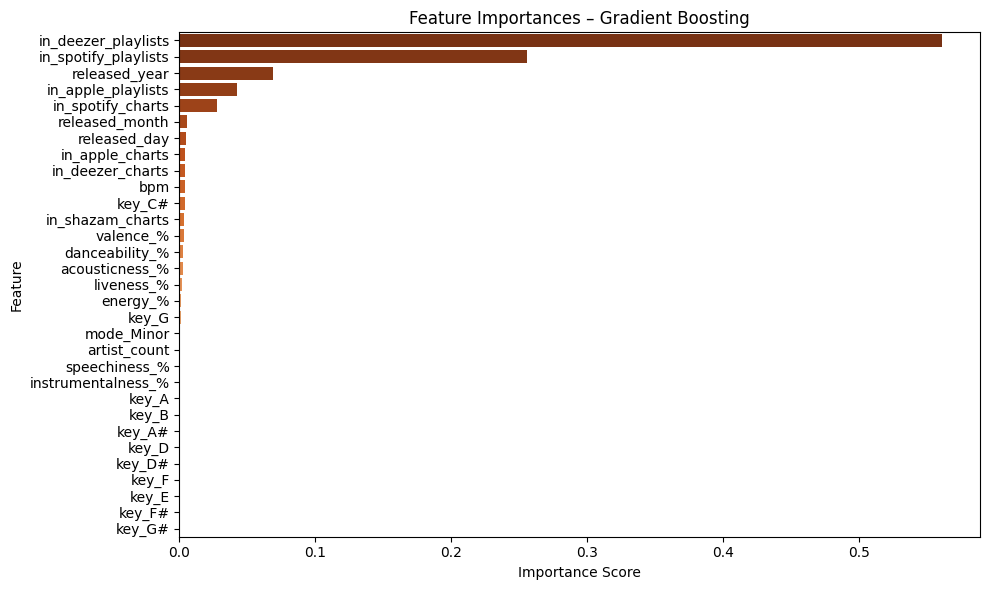

In [ ]:
gbr_importances = pd.Series(best_gbr.feature_importances_, index=X_train_s.columns)
gbr_importances_sorted = gbr_importances.sort_values(ascending=False)

print('Feature Importances – Gradient Boosting (descending):')
print(gbr_importances_sorted)
print()
unused_gbr = gbr_importances_sorted[gbr_importances_sorted == 0]
if len(unused_gbr) > 0:
    print(f'Unused predictors (importance = 0): {unused_gbr.index.tolist()}')
else:
    print('All predictors were used by the Gradient Boosting model.')

plt.figure(figsize=(10, 6))
sns.barplot(x=gbr_importances_sorted.values, y=gbr_importances_sorted.index, palette='Oranges_r')
plt.title('Feature Importances – Gradient Boosting')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

11. Compare the results of the random forest to the boosted tree model.  Which one is better?  Justify your choice.


In [ ]:
comparison_df = pd.DataFrame({
    'Metric': ['RMSE (Train)', 'R² (Train)', 'RMSE (Validation)', 'R² (Validation)', 'RMSE (Test)', 'R² (Test)'],
    'Random Forest': [
        f'{rmse_train_rf:,.0f}', f'{r2_train_rf:.4f}',
        f'{rmse_val_rf:,.0f}',   f'{r2_val_rf:.4f}',
        f'{rmse_test_rf:,.0f}',  f'{r2_test_rf:.4f}'
    ],
    'Gradient Boosting': [
        f'{rmse_train_gbr:,.0f}', f'{r2_train_gbr:.4f}',
        f'{rmse_val_gbr:,.0f}',   f'{r2_val_gbr:.4f}',
        f'{rmse_test_gbr:,.0f}',  f'{r2_test_gbr:.4f}'
    ]
})
comparison_df = comparison_df.set_index('Metric')
print('Model Comparison – Spotify Streams Prediction')
print(comparison_df.to_string())

Model Comparison – Spotify Streams Prediction
                  Random Forest Gradient Boosting
Metric                                           
RMSE (Train)        111,766,885       144,184,619
R² (Train)               0.9652            0.9422
RMSE (Validation)   218,117,423       185,384,801
R² (Validation)          0.8270            0.8750
RMSE (Test)         227,820,298       213,231,398
R² (Test)                0.7880            0.8143


The gradient boosting model is better than the random forest since the test and validation RSME is lower meaning the model's predictions are closer to the actual values. Secondly, gradient boosting has higher R squared on validation and test sets than random forestshowing the model caught onto more patterns in the data than the latter

12. Read in the Telco dataset and determine how many rows and columns it has.


In [ ]:
df_telco = pd.read_csv('/content/drive/MyDrive/OPIM 5604 Python/Datasets/Telco_customer_churn (1).csv')

In [ ]:
df_telco.shape

(7043, 18)

This data set has 7043 rows and 18 columns

In [ ]:
df_telco.dtypes

,0
CustomerID,object
Gender,object
Senior Citizen,object
Partner,object
Dependents,object
Tenure Months,int64
Multiple Lines,object
Internet Service,object
Online Security,object
Online Backup,object


In [ ]:
print(df_telco.head())

   CustomerID  Gender Senior Citizen Partner Dependents  Tenure Months  \
0  3668-QPYBK    Male             No      No         No              2   
1  9237-HQITU  Female             No      No        Yes              2   
2  9305-CDSKC  Female             No      No        Yes              8   
3  7892-POOKP  Female             No     Yes        Yes             28   
4  0280-XJGEX    Male             No      No        Yes             49   

  Multiple Lines Internet Service Online Security Online Backup  \
0             No              DSL             Yes           Yes   
1             No      Fiber optic              No            No   
2            Yes      Fiber optic              No            No   
3            Yes      Fiber optic              No            No   
4            Yes      Fiber optic              No           Yes   

  Device Protection Tech Support        Contract Paperless Billing  \
0                No           No  Month-to-month               Yes   
1           

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Data preparation for KNN
# Drop non-predictive identifier columns
telco_model = df_telco.drop(columns=['CustomerID', 'Churn Label'], errors='ignore')

# Encode remaining categorical columns
cat_cols_telco = telco_model.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode: {cat_cols_telco}')

le_telco = LabelEncoder()
for col in cat_cols_telco:
    telco_model[col] = le_telco.fit_transform(telco_model[col].astype(str))

# Check for missing values
print(f'\nMissing values: {telco_model.isnull().sum().sum()}')
telco_model = telco_model.dropna()
print(f'Shape after cleaning: {telco_model.shape}')

Categorical columns to encode: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Contract', 'Paperless Billing', 'Electronic Check']

Missing values: 0
Shape after cleaning: (7043, 16)


13. Partition the data into a 60/20/20 split.


In [ ]:
target_telco = 'Churn Value'
X_telco = telco_model.drop(columns=[target_telco])
y_telco = telco_model[target_telco]

# Scale features — required for KNN (distance-based algorithm)
scaler = StandardScaler()
X_telco_scaled = scaler.fit_transform(X_telco)
X_telco_scaled = pd.DataFrame(X_telco_scaled, columns=X_telco.columns)

# 60 / 40 split
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X_telco_scaled, y_telco, test_size=0.40, random_state=42, stratify=y_telco)

# 50 / 50 of remaining = 20 / 20
X_va, X_te, y_va, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp)

print('Partition sizes (60 / 20 / 20):')
print(f'  Training   : {X_tr.shape[0]} rows')
print(f'  Validation : {X_va.shape[0]} rows')
print(f'  Test       : {X_te.shape[0]} rows')

Partition sizes (60 / 20 / 20):
  Training   : 4225 rows
  Validation : 1409 rows
  Test       : 1409 rows


14. Build a KNN model to predict churn using all predictors.


# KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Build an initial KNN model with a default K=5
knn_initial = KNeighborsClassifier(n_neighbors=5)
knn_initial.fit(X_tr, y_tr)

y_tr_pred_initial = knn_initial.predict(X_tr)
y_va_pred_initial = knn_initial.predict(X_va)

print('Initial KNN (K=5) – Accuracy')
print(f'  Training   Accuracy: {accuracy_score(y_tr, y_tr_pred_initial):.4f}')
print(f'  Validation Accuracy: {accuracy_score(y_va, y_va_pred_initial):.4f}')

Initial KNN (K=5) – Accuracy
  Training   Accuracy: 0.8395
  Validation Accuracy: 0.7864


15. What is the best value for K?  How do you know?


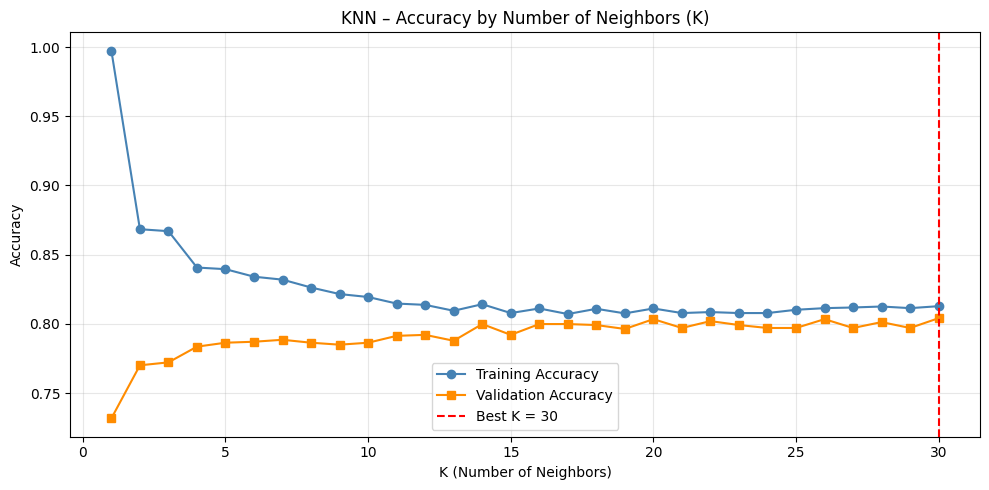

In [ ]:
# Test K values from 1 to 30 and evaluate on the validation set
k_values = range(1, 31)
train_accuracies = []
val_accuracies   = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_tr, y_tr)
    train_accuracies.append(accuracy_score(y_tr, knn.predict(X_tr)))
    val_accuracies.append(accuracy_score(y_va, knn.predict(X_va)))

# Identify the best K based on validation accuracy
best_k_idx = np.argmax(val_accuracies)
best_k     = k_values[best_k_idx]
best_val_acc = val_accuracies[best_k_idx]


# Plot K vs. Accuracy
plt.figure(figsize=(10, 5))
plt.plot(k_values, train_accuracies, marker='o', label='Training Accuracy', color='steelblue')
plt.plot(k_values, val_accuracies,   marker='s', label='Validation Accuracy', color='darkorange')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.title('KNN – Accuracy by Number of Neighbors (K)')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The best K value is 30 because there is more balance in bias and variance than the rest.

16. Re-run the model with the optimal K.  Check model performance by partition with total accuracy, precision, recall, and F1 score.


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train final KNN model with the best K
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_tr, y_tr)

# Predictions
y_tr_pred = knn_best.predict(X_tr)
y_va_pred = knn_best.predict(X_va)
y_te_pred = knn_best.predict(X_te)

def knn_metrics(y_true, y_pred, partition_name):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    print(f'  {partition_name:<12} | Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}')
    return acc, prec, rec, f1

print(f'KNN (K={best_k}) – Performance by Partition')
print('-' * 75)
acc_tr,  prec_tr,  rec_tr,  f1_tr  = knn_metrics(y_tr, y_tr_pred, 'Training')
acc_va,  prec_va,  rec_va,  f1_va  = knn_metrics(y_va, y_va_pred, 'Validation')
acc_te,  prec_te,  rec_te,  f1_te  = knn_metrics(y_te, y_te_pred, 'Test')

KNN (K=30) – Performance by Partition
---------------------------------------------------------------------------
  Training     | Accuracy: 0.8128 | Precision: 0.6701 | Recall: 0.5798 | F1: 0.6217
  Validation   | Accuracy: 0.8041 | Precision: 0.6512 | Recall: 0.5642 | F1: 0.6046
  Test         | Accuracy: 0.7842 | Precision: 0.5989 | Recall: 0.5668 | F1: 0.5824



Detailed Classification Report – Test Set (K=30):
              precision    recall  f1-score   support

No Churn (0)       0.85      0.86      0.85      1035
   Churn (1)       0.60      0.57      0.58       374

    accuracy                           0.78      1409
   macro avg       0.72      0.71      0.72      1409
weighted avg       0.78      0.78      0.78      1409



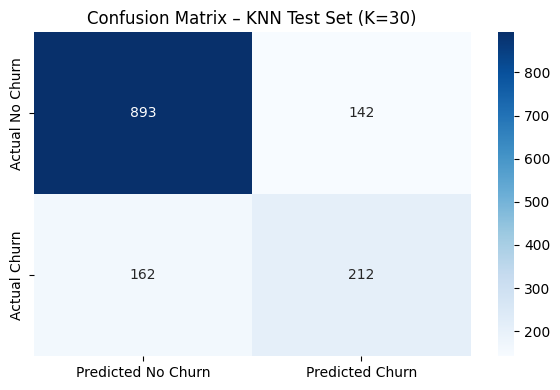

In [ ]:
# Full classification report for the test set
print(f'\nDetailed Classification Report – Test Set (K={best_k}):')
print(classification_report(y_te, y_te_pred, target_names=['No Churn (0)', 'Churn (1)']))

# Confusion Matrix
cm = confusion_matrix(y_te, y_te_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title(f'Confusion Matrix – KNN Test Set (K={best_k})')
plt.tight_layout()
plt.show()

In [ ]:
# Summary comparison table
knn_summary = pd.DataFrame({
    'Partition':  ['Training', 'Validation', 'Test'],
    'Accuracy':   [acc_tr,  acc_va,  acc_te],
    'Precision':  [prec_tr, prec_va, prec_te],
    'Recall':     [rec_tr,  rec_va,  rec_te],
    'F1 Score':   [f1_tr,   f1_va,   f1_te]
})
knn_summary = knn_summary.set_index('Partition').round(4)
print(f'\nKNN (K={best_k}) Summary Table:')
print(knn_summary.to_string())


KNN (K=30) Summary Table:
            Accuracy  Precision  Recall  F1 Score
Partition                                        
Training      0.8128     0.6701  0.5798    0.6217
Validation    0.8041     0.6512  0.5642    0.6046
Test          0.7842     0.5989  0.5668    0.5824


The KNN model has good accuracy overall and seems to be performing well but can be further improved upon.